# Laboratorio 7
**Nombre del curso:** MM3014 Teoría de Probabilidades  
**Nombre y apellido:** Samuel Robledo (241282)  
**Fecha:** 20/05/2026  

## Introducción

En este laboratorio se simula el proceso de llenado de un álbum de estampas Panini del Mundial FIFA 2026 mediante métodos de Monte Carlo. El objetivo es estimar el número esperado de sobres necesarios para completar la colección, la cantidad de estampas repetidas, el costo aproximado y la probabilidad de éxito al comprar una cantidad fija de sobres. Además, los resultados simulados se comparan con la teoría del coleccionista para entender mejor por qué el final del álbum suele ser la parte más difícil.

## Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

## Parámetros generales

In [4]:
SEMILLA = 2026
N = 100
S = 7
R = 10000

PRECIO_SOBRE = 9.50
PRECIO_CAJA = 975.00
SOBRES_POR_CAJA = 104

np.random.seed(SEMILLA)

## Etapa 1: Simulación básica con álbum reducido

Primero se trabaja con un álbum reducido de 100 estampas para que el experimento pueda repetirse muchas veces. En cada simulación se compran sobres hasta completar todas las estampas del álbum.

In [5]:
def simular_album(N, S):
    obtenidas = np.zeros(N, dtype=bool)
    sobres_comprados = 0
    repetidas = 0
    total_obtenidas = 0
    
    while total_obtenidas < N:
        sobre = np.random.choice(N, size=S, replace=False)
        sobres_comprados += 1
        
        for estampa in sobre:
            if obtenidas[estampa]:
                repetidas += 1
            else:
                obtenidas[estampa] = True
                total_obtenidas += 1
    
    return sobres_comprados, repetidas

In [6]:
sobres_necesarios = []
repetidas_totales = []

for _ in range(R):
    sobres, repetidas = simular_album(N, S)
    sobres_necesarios.append(sobres)
    repetidas_totales.append(repetidas)

sobres_necesarios = np.array(sobres_necesarios)
repetidas_totales = np.array(repetidas_totales)

In [7]:
media_sobres = np.mean(sobres_necesarios)
std_sobres = np.std(sobres_necesarios, ddof=1)
media_repetidas = np.mean(repetidas_totales)
std_repetidas = np.std(repetidas_totales, ddof=1)
prob_mas_30 = np.mean(sobres_necesarios > 30)
minimo_teorico = math.ceil(N / S)

costo_promedio_sobres = media_sobres * PRECIO_SOBRE
cajas_promedio = math.ceil(media_sobres / SOBRES_POR_CAJA)
costo_promedio_cajas = cajas_promedio * PRECIO_CAJA

print("Resultados de la Etapa 1")
print(f"Media de sobres necesarios: {media_sobres:.2f}")
print(f"Desviación estándar de sobres necesarios: {std_sobres:.2f}")
print(f"Media de estampas repetidas: {media_repetidas:.2f}")
print(f"Desviación estándar de estampas repetidas: {std_repetidas:.2f}")
print(f"Probabilidad de necesitar más de 30 sobres: {prob_mas_30:.4f}")
print(f"Mínimo teórico de sobres sin repetidas: {minimo_teorico}")
print(f"Costo promedio comprando sobres individuales: Q {costo_promedio_sobres:.2f}")
print(f"Cajas necesarias aproximadas para la media: {cajas_promedio}")
print(f"Costo aproximado comprando cajas completas: Q {costo_promedio_cajas:.2f}")

Resultados de la Etapa 1
Media de sobres necesarios: 72.25
Desviación estándar de sobres necesarios: 17.47
Media de estampas repetidas: 405.72
Desviación estándar de estampas repetidas: 122.31
Probabilidad de necesitar más de 30 sobres: 1.0000
Mínimo teórico de sobres sin repetidas: 15
Costo promedio comprando sobres individuales: Q 686.33
Cajas necesarias aproximadas para la media: 1
Costo aproximado comprando cajas completas: Q 975.00


## Teoría del coleccionista

In [8]:
H_N_exacto = sum(1 / k for k in range(1, N + 1))
gamma = 0.5772
H_N_aprox = np.log(N) + gamma
E_T_exacto = (N / S) * H_N_exacto
E_T_aprox = (N / S) * H_N_aprox
repetidas_teoricas = S * E_T_exacto - N

print("Teoría del coleccionista")
print(f"H_N exacto: {H_N_exacto:.4f}")
print(f"H_N aproximado: {H_N_aprox:.4f}")
print(f"E[T] exacto aproximado: {E_T_exacto:.2f} sobres")
print(f"E[T] usando ln(N) + gamma: {E_T_aprox:.2f} sobres")
print(f"Repetidas teóricas esperadas: {repetidas_teoricas:.2f}")

Teoría del coleccionista
H_N exacto: 5.1874
H_N aproximado: 5.1824
E[T] exacto aproximado: 74.11 sobres
E[T] usando ln(N) + gamma: 74.03 sobres
Repetidas teóricas esperadas: 418.74


## Tabla resumen de la Etapa 1

In [9]:
resumen_etapa1 = pd.DataFrame({
    "Medida": [
        "Media de sobres",
        "Desviación estándar de sobres",
        "Media de repetidas",
        "Desviación estándar de repetidas",
        "Probabilidad de más de 30 sobres",
        "Mínimo teórico sin repetidas",
        "Valor esperado teórico de sobres",
        "Repetidas teóricas esperadas",
        "Costo promedio en sobres individuales"
    ],
    "Valor": [
        media_sobres,
        std_sobres,
        media_repetidas,
        std_repetidas,
        prob_mas_30,
        minimo_teorico,
        E_T_exacto,
        repetidas_teoricas,
        costo_promedio_sobres
    ]
})

resumen_etapa1

,Medida,Valor
0,Media de sobres,72.245600
1,Desviación estándar de sobres,17.472384
2,Media de repetidas,405.719200
3,Desviación estándar de repetidas,122.306689
4,Probabilidad de más de 30 sobres,1.000000
5,Mínimo teórico sin repetidas,15.000000
6,Valor esperado teórico de sobres,74.105393
7,Repetidas teóricas esperadas,418.737752
8,Costo promedio en sobres individuales,686.333200


## Histograma de sobres necesarios

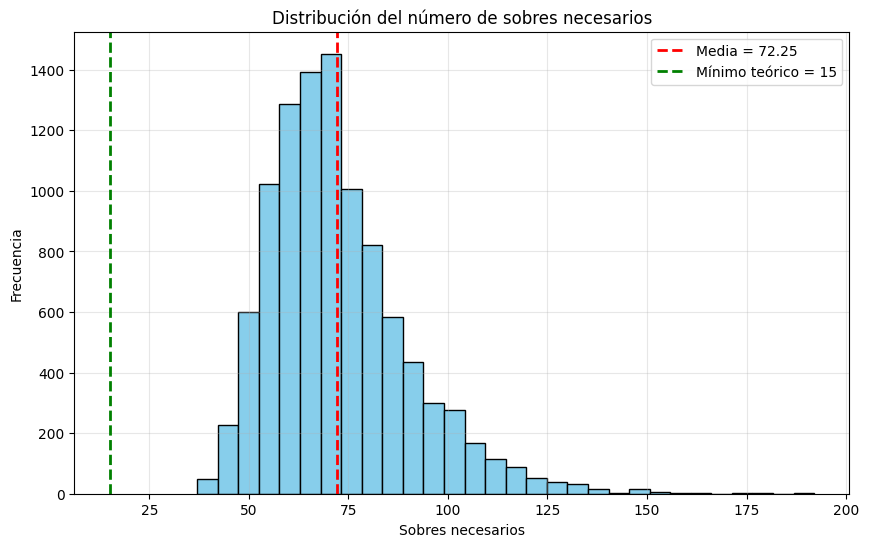

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(sobres_necesarios, bins=30, color="skyblue", edgecolor="black")
plt.axvline(media_sobres, color="red", linestyle="--", linewidth=2, label=f"Media = {media_sobres:.2f}")
plt.axvline(minimo_teorico, color="green", linestyle="--", linewidth=2, label=f"Mínimo teórico = {minimo_teorico}")
plt.title("Distribución del número de sobres necesarios")
plt.xlabel("Sobres necesarios")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Valores para responder las preguntas de la Etapa 1

In [11]:
casos_minimo = np.sum(sobres_necesarios == minimo_teorico)

print("Valores para responder - Etapa 1")
print(f"Mínimo teórico: ceil({N} / {S}) = {minimo_teorico} sobres")
print(f"Casos observados con exactamente el mínimo teórico: {casos_minimo}")
print(f"Media simulada de sobres: {media_sobres:.2f}")
print(f"E[T] teórico exacto: {E_T_exacto:.2f}")
print(f"H_100 exacto: {H_N_exacto:.4f}")
print(f"H_100 aproximado: {H_N_aprox:.4f}")
print(f"Media simulada de repetidas: {media_repetidas:.2f}")
print(f"Repetidas teóricas esperadas: {repetidas_teoricas:.2f}")
print(f"Desviación estándar de sobres: {std_sobres:.2f}")
print(f"Relación desviación/media: {std_sobres / media_sobres:.4f}")
print(f"Probabilidad de necesitar más de 30 sobres: {prob_mas_30:.4f}")

Valores para responder - Etapa 1
Mínimo teórico: ceil(100 / 7) = 15 sobres
Casos observados con exactamente el mínimo teórico: 0
Media simulada de sobres: 72.25
E[T] teórico exacto: 74.11
H_100 exacto: 5.1874
H_100 aproximado: 5.1824
Media simulada de repetidas: 405.72
Repetidas teóricas esperadas: 418.74
Desviación estándar de sobres: 17.47
Relación desviación/media: 0.2418
Probabilidad de necesitar más de 30 sobres: 1.0000


## Análisis de la Etapa 1

**1. Número mínimo de sobres**

El número mínimo de sobres se obtiene dividiendo la cantidad total de estampas entre la cantidad de estampas por sobre. En este caso:

Mínimo teórico = techo(100 / 7) = 15 sobres

Esto significa que, en el mejor escenario posible, se necesitarían 15 sobres para completar el álbum reducido. Sin embargo, en las simulaciones no apareció ningún caso con exactamente 15 sobres. Esto es razonable, porque aunque dentro de un mismo sobre no se repiten estampas, entre sobres sí pueden aparecer repetidas. Por eso, en la práctica se necesita una cantidad mucho mayor que el mínimo teórico.

**2. Comparación con la teoría del coleccionista**

Según la teoría del coleccionista, el número esperado de sobres se estima como:

E[T] ≈ (N / S) * H_N

Para este laboratorio se calculó H_100 de forma exacta, obteniendo 5.1874. También se usó la aproximación ln(100) + 0.5772, que dio 5.1824. Con el valor exacto, el número esperado teórico fue de 74.11 sobres.

La media obtenida en la simulación fue de 72.25 sobres, por lo que ambos valores son bastante cercanos. La diferencia se explica por la variabilidad propia de la simulación aleatoria, aunque se haya usado una semilla fija para reproducir los resultados.

**3. Estampas repetidas esperadas**

El valor esperado teórico de estampas repetidas se estimó como:

Repetidas esperadas = S * E[T] - N

Con este cálculo se obtuvo un valor teórico aproximado de 418.74 estampas repetidas. En la simulación, la media de repetidas fue de 405.72. Estos valores son cercanos y muestran que el modelo simulado representa de forma razonable el comportamiento esperado.

Además, este resultado confirma que una gran parte de las estampas compradas terminan siendo repetidas, especialmente cuando el álbum ya está avanzado y faltan pocas estampas por conseguir.

**4. Interpretación de la desviación estándar**

La desviación estándar del número de sobres fue de 17.47. Este valor indica que existe una variación considerable entre una simulación y otra. En relación con la media de 72.25 sobres, representa aproximadamente un 24.18%.

Esta variabilidad es alta porque el proceso de coleccionar no avanza de forma uniforme. Al inicio es común obtener estampas nuevas, pero conforme el álbum se llena, cada vez es más probable recibir estampas repetidas. Por eso algunas simulaciones completan el álbum relativamente rápido, mientras que otras necesitan muchos más sobres.

## Etapa 2: Análisis de probabilidad de éxito según el número de sobres

Ahora se evalúa la probabilidad de completar el álbum comprando una cantidad fija de sobres. Para cada valor de $M$, se realizan 10000 simulaciones y se registra si el álbum quedó completo al terminar esos sobres.

In [12]:
def simular_exito_con_M(N, S, M, R):
    exitos = 0
    
    for _ in range(R):
        obtenidas = np.zeros(N, dtype=bool)
        
        for _ in range(M):
            sobre = np.random.choice(N, size=S, replace=False)
            obtenidas[sobre] = True
        
        if np.all(obtenidas):
            exitos += 1
    
    return exitos / R

In [13]:
M_valores = [20, 25, 30, 35, 40, 45, 50, 60, 70, 80]

probabilidades = []
for M in M_valores:
    probabilidad = simular_exito_con_M(N, S, M, R)
    probabilidades.append(probabilidad)

resultados_etapa2 = pd.DataFrame({
    "M_sobres": M_valores,
    "Probabilidad_estimada": probabilidades
})
resultados_etapa2["Probabilidad_falla"] = 1 - resultados_etapa2["Probabilidad_estimada"]

resultados_etapa2

,M_sobres,Probabilidad_estimada,Probabilidad_falla
0,20,0.0000,1.0000
1,25,0.0000,1.0000
2,30,0.0000,1.0000
3,35,0.0000,1.0000
4,40,0.0023,0.9977
5,45,0.0152,0.9848
6,50,0.0587,0.9413
7,60,0.2692,0.7308
8,70,0.5198,0.4802
9,80,0.7403,0.2597


## Visualización de la Etapa 2

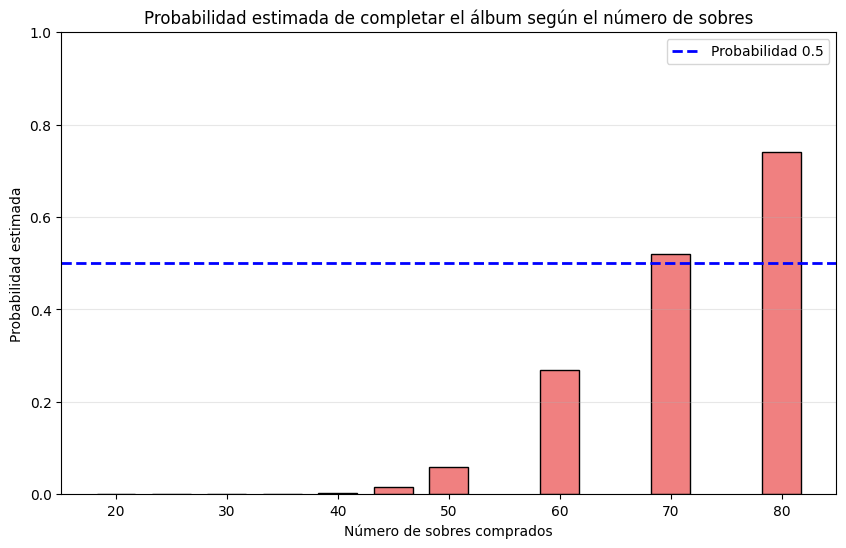

In [14]:
plt.figure(figsize=(10, 6))
plt.bar(resultados_etapa2["M_sobres"], resultados_etapa2["Probabilidad_estimada"], color="lightcoral", edgecolor="black", width=3.5)
plt.axhline(0.5, color="blue", linestyle="--", linewidth=2, label="Probabilidad 0.5")
plt.title("Probabilidad estimada de completar el álbum según el número de sobres")
plt.xlabel("Número de sobres comprados")
plt.ylabel("Probabilidad estimada")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

## Cálculos para responder la Etapa 2

In [15]:
primer_50 = None
primer_90 = None

for _, fila in resultados_etapa2.iterrows():
    if primer_50 is None and fila["Probabilidad_estimada"] >= 0.5:
        primer_50 = int(fila["M_sobres"])
    if primer_90 is None and fila["Probabilidad_estimada"] >= 0.9:
        primer_90 = int(fila["M_sobres"])

mediana_sobres = np.median(sobres_necesarios)

M_cota = 50
cota_falla = N * np.exp(-M_cota * S / N)
cota_falla_truncada = min(1, cota_falla)
prob_exito_M50 = float(resultados_etapa2.loc[resultados_etapa2["M_sobres"] == M_cota, "Probabilidad_estimada"].iloc[0])
prob_falla_M50 = 1 - prob_exito_M50

texto_50 = primer_50 if primer_50 is not None else "No se alcanza en los valores evaluados"
texto_90 = primer_90 if primer_90 is not None else "No se alcanza en los valores evaluados"

print("Valores para responder - Etapa 2")
print(f"Primer M con probabilidad >= 50%: {texto_50}")
print(f"Primer M con probabilidad >= 90%: {texto_90}")
print(f"Mediana de sobres necesarios en Etapa 1: {mediana_sobres:.2f}")
print(f"Probabilidad estimada de éxito con M = 50: {prob_exito_M50:.4f}")
print(f"Probabilidad estimada de falla con M = 50: {prob_falla_M50:.4f}")
print(f"Cota de falla para M = 50: {cota_falla:.4f}")
print(f"Cota de falla truncada a 1: {cota_falla_truncada:.4f}")

Valores para responder - Etapa 2
Primer M con probabilidad >= 50%: 70
Primer M con probabilidad >= 90%: No se alcanza en los valores evaluados
Mediana de sobres necesarios en Etapa 1: 69.00
Probabilidad estimada de éxito con M = 50: 0.0587
Probabilidad estimada de falla con M = 50: 0.9413
Cota de falla para M = 50: 3.0197
Cota de falla truncada a 1: 1.0000


In [16]:
print("Respuestas automáticas basadas en los resultados calculados")
print(f"1. El primer valor de M con probabilidad al menos 50% es: {texto_50}.")
print(f"   El primer valor de M con probabilidad al menos 90% es: {texto_90}.")
print(f"2. La mediana de sobres de la Etapa 1 es {mediana_sobres:.2f}.")
if primer_50 is not None:
    print(f"   Este valor se compara con M = {primer_50}, que es el primer punto evaluado con al menos 50% de éxito.")
else:
    print("   En los valores evaluados no se llegó al 50%, por lo que no hay un M comparable dentro de la tabla.")
print(f"3. Para M = 50, la falla simulada es {prob_falla_M50:.4f}.")
print(f"   La cota por unión es {cota_falla:.4f}, y truncada a 1 es {cota_falla_truncada:.4f}.")

Respuestas automáticas basadas en los resultados calculados
1. El primer valor de M con probabilidad al menos 50% es: 70.
   El primer valor de M con probabilidad al menos 90% es: No se alcanza en los valores evaluados.
2. La mediana de sobres de la Etapa 1 es 69.00.
   Este valor se compara con M = 70, que es el primer punto evaluado con al menos 50% de éxito.
3. Para M = 50, la falla simulada es 0.9413.
   La cota por unión es 3.0197, y truncada a 1 es 1.0000.


## Análisis de la Etapa 2

**1. Probabilidad de éxito del 50% y 90%**

La probabilidad estimada de completar el álbum supera por primera vez el 50% cuando se compran 70 sobres. Para ese valor, la probabilidad de éxito fue de 0.5198, es decir, aproximadamente 51.98%.

En cambio, la probabilidad del 90% no se alcanzó dentro de los valores evaluados. Incluso con 80 sobres, la probabilidad estimada fue de 0.7403, por lo que todavía haría falta comprar más sobres para acercarse a una probabilidad de éxito del 90%.

**2. Comparación con la mediana de la Etapa 1**

La mediana del número de sobres necesarios en la Etapa 1 fue de 69.00 sobres. Este valor es muy cercano a los 70 sobres encontrados en la Etapa 2 para superar el 50% de probabilidad de completar el álbum.

Esto tiene sentido porque la mediana representa el punto donde aproximadamente la mitad de las simulaciones ya completaron el álbum y la otra mitad todavía no. Por eso, el valor de M que da una probabilidad cercana al 50% debe parecerse bastante a la mediana del número de sobres necesarios.

**3. Cota superior para la probabilidad de falla con M = 50**

Para M = 50 sobres, la probabilidad estimada de éxito fue de 0.0587, por lo que la probabilidad simulada de falla fue de 0.9413.

Usando la aproximación teórica, la cota superior para la probabilidad de que falte al menos una estampa fue de 3.0197. Como una probabilidad no puede ser mayor que 1, esta cota se puede truncar a 1.0000.

Al comparar la cota truncada con la probabilidad de falla simulada, se observa que sí funciona como límite superior, pero no es una estimación muy precisa. En este caso, la cota es conservadora porque sobreestima la probabilidad real de falla.

## Conclusiónes
A partir de las simulaciones realizadas, se puede concluir que el proceso de completar un álbum de estampas sigue el comportamiento esperado del problema del coleccionista. Aunque el mínimo teórico para completar el álbum reducido era de 15 sobres, en la práctica se necesitó una cantidad mucho mayor debido a la aparición de estampas repetidas.

La media simulada del número de sobres necesarios fue de 72.25, mientras que el valor esperado teórico fue de 74.11 sobres. Esta cercanía muestra que la simulación representa de forma adecuada el fenómeno estudiado. Además, se observó que la cantidad de estampas repetidas también fue alta, lo cual confirma que el principal problema al llenar un álbum no es solo comprar suficientes estampas, sino conseguir las que todavía faltan.

En la segunda etapa se comprobó que la probabilidad de completar el álbum aumenta conforme se compran más sobres. Sin embargo, para los valores evaluados, se necesitó llegar hasta 70 sobres para superar el 50% de probabilidad de éxito, y ni siquiera con 80 sobres se alcanzó el 90%.

Finalmente, el laboratorio permite observar que la parte final del álbum es la más difícil, ya que cuando faltan pocas estampas, la probabilidad de obtener una nueva disminuye y aparecen muchas más repetidas. Por esta razón, el número real de sobres necesarios suele ser mucho mayor que el mínimo teórico.

## Uso de inteligencia artificial

Se utilizó inteligencia artificial como herramienta de apoyo para estructurar el notebook, revisar el código, ordenar los resultados y mejorar la redacción de las respuestas. Los cálculos y simulaciones fueron verificados dentro del notebook, manteniendo el análisis basado en los resultados obtenidos y en los conceptos vistos en el curso.